In [2]:
import pandas as pd

day_1 = pd.read_csv('../../round_data/prices_round_4_day_1.csv', delimiter=';')
day_2 = pd.read_csv('../../round_data/prices_round_4_day_2.csv', delimiter=';')
day_3 = pd.read_csv('../../round_data/prices_round_4_day_3.csv', delimiter=';')

In [3]:
day_2.timestamp += 1e6
day_3.timestamp += 2e6

In [4]:
prices = pd.concat([day_1,day_2,day_3])

In [5]:
product_names = list(prices['product'].unique())

In [6]:
price_dfs = {name:prices[prices['product']==name].reset_index(drop=True)for name in product_names}

In [7]:
import matplotlib.pyplot as plt
import numpy as np

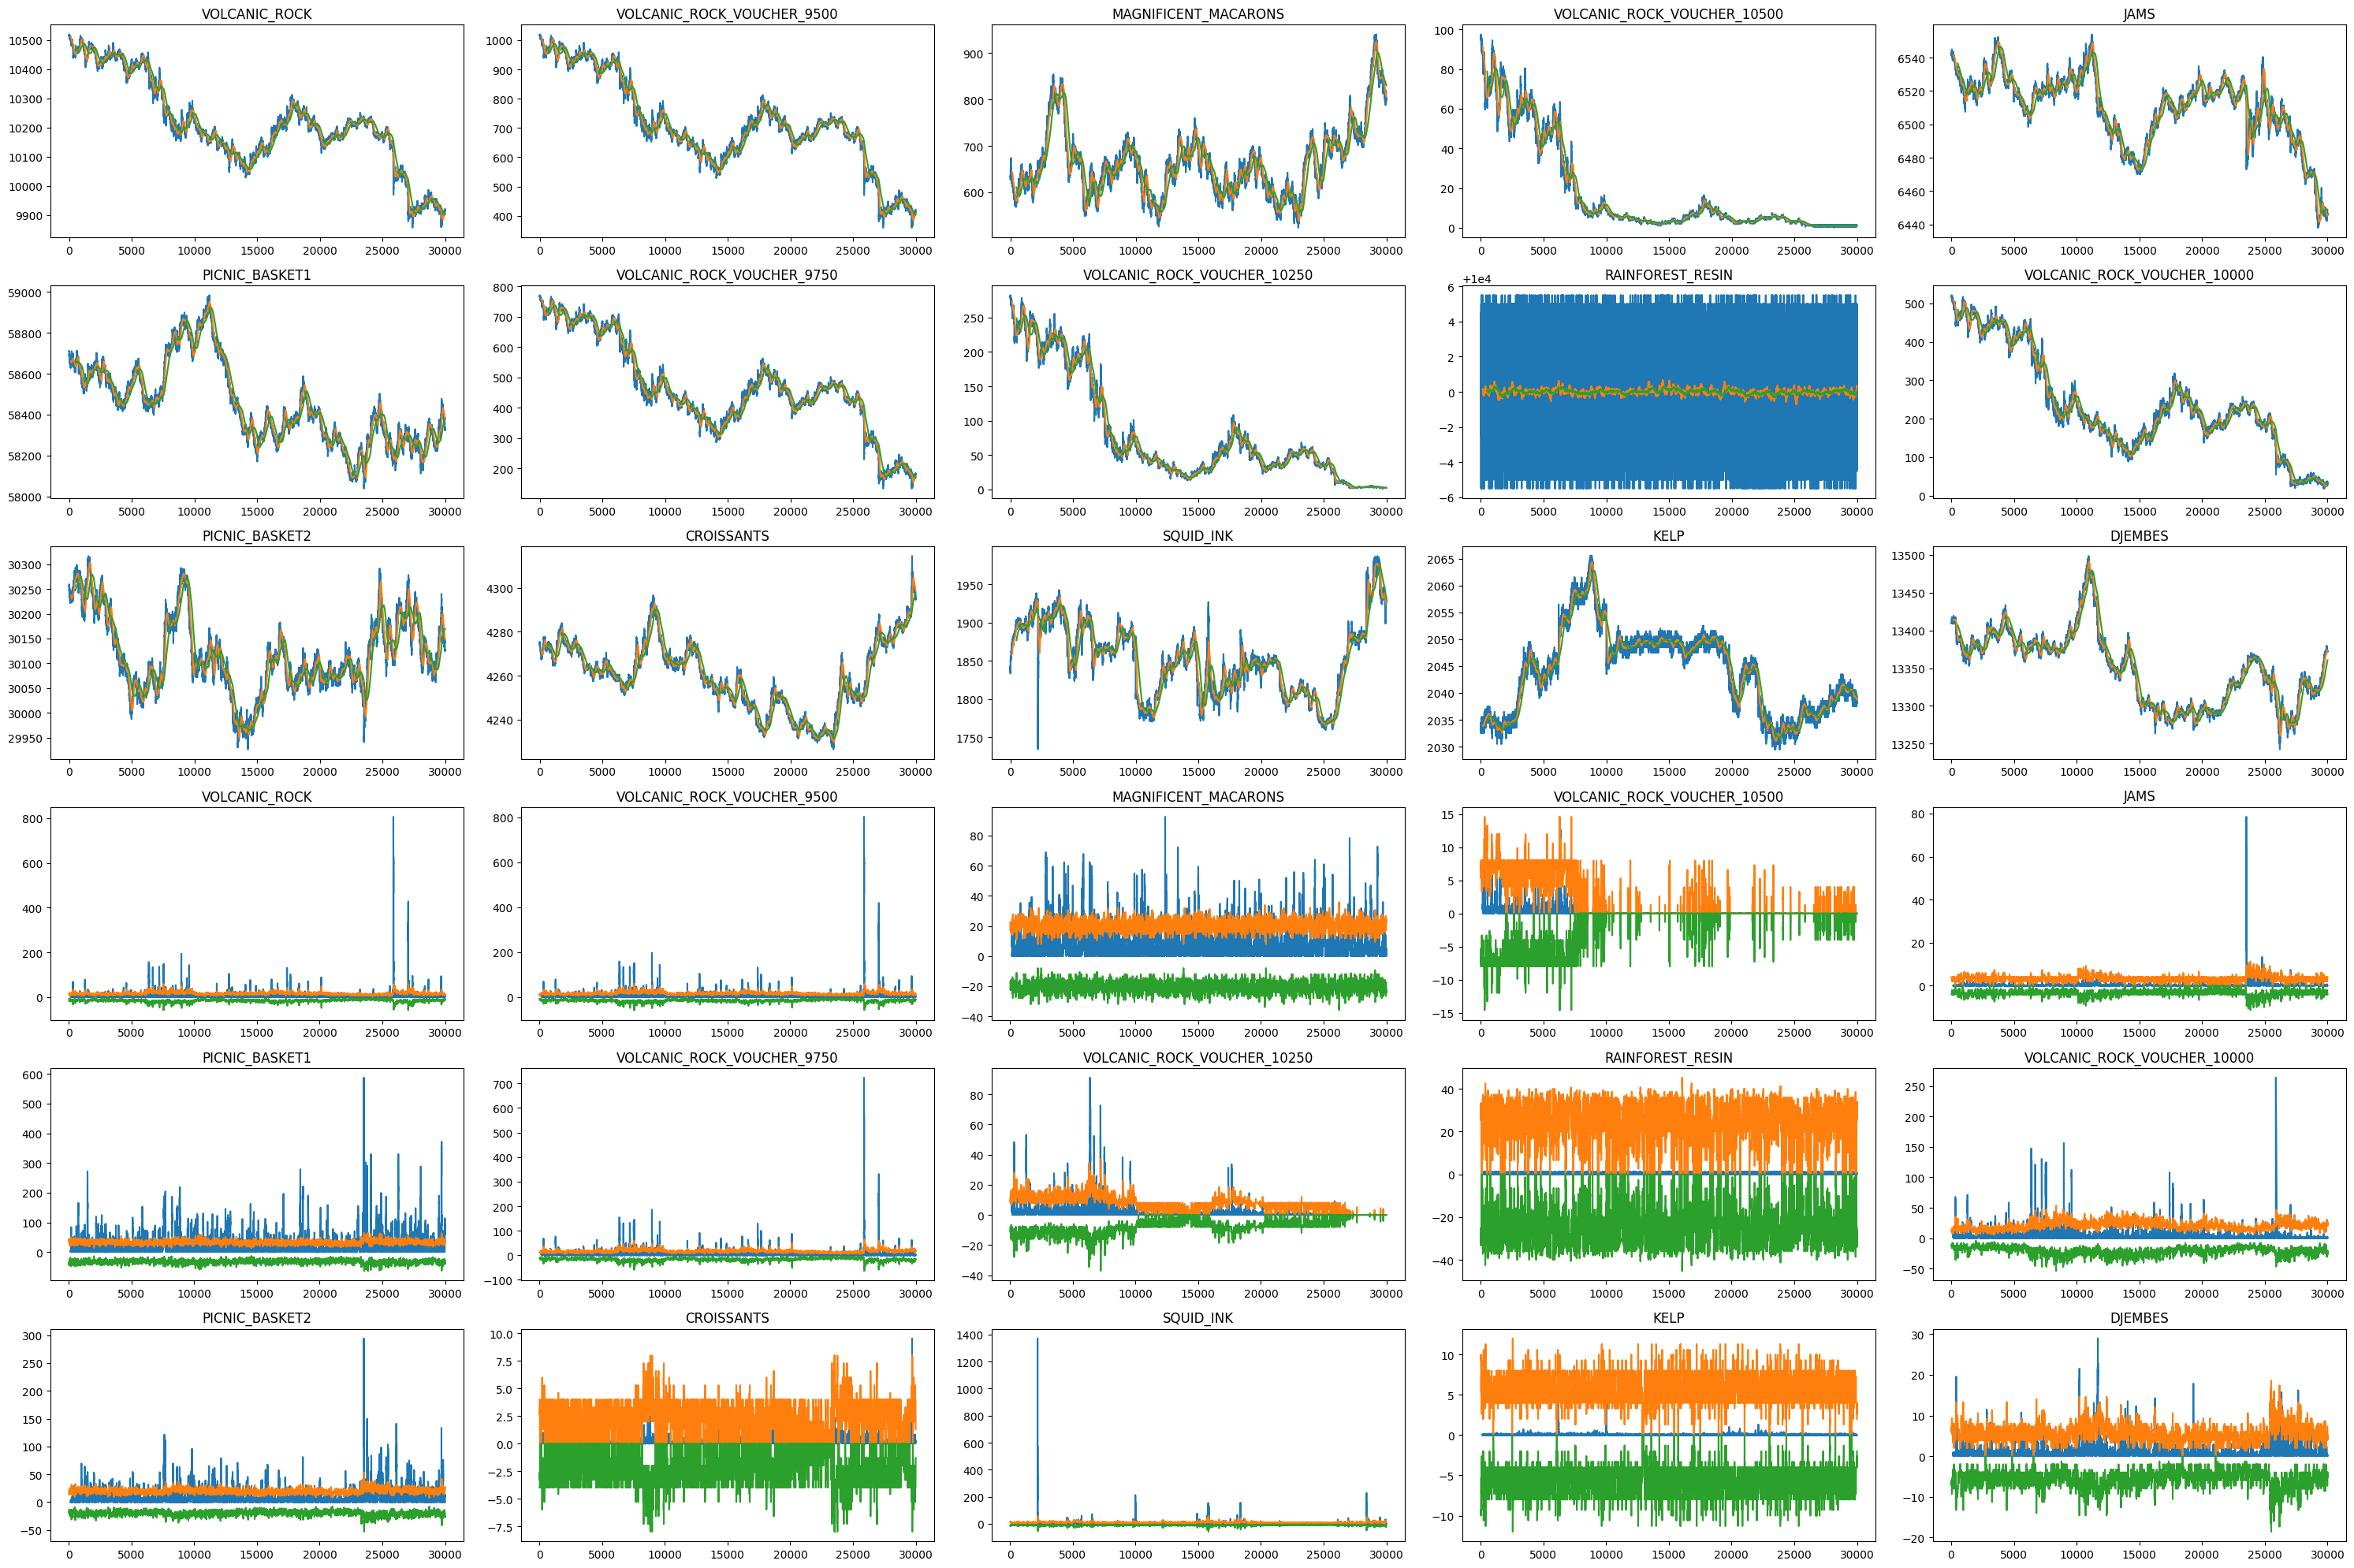

In [8]:
fig,ax = plt.subplots(ncols=5,nrows=6,figsize=(30,20))
for i, key in enumerate(price_dfs):
    row_num = i%3
    col_num = i//3
    df = price_dfs[key]
    ax[row_num,col_num].plot(df.mid_price)
    ax[row_num,col_num].plot(df.mid_price.rolling(150).mean())
    ax[row_num,col_num].plot(df.mid_price.rolling(500).mean())
    ax[row_num,col_num].set_title(key)
    
    # Short term mean reversion
    signal1 = df.mid_price.rolling(50).mean()-df.mid_price
    # Longer term mean reversion
    signal2 = (df.mid_price.rolling(150).quantile(0.25)+df.mid_price.rolling(150).quantile(0.75))/2-df.mid_price
    # Short term trend
    signal3 = ((df.mid_price.rolling(12).quantile(0.75)-df.mid_price.rolling(12).quantile(0.25))/12)**2*np.sign(df.mid_price.diff(12))
    # ax[row_num+3,col_num].plot(signal1)
    # ax[row_num+3,col_num].plot(signal2)
    # ax[row_num+3,col_num].plot(signal3.clip(-10,10))
    
    bound = df.mid_price.diff().rolling(30).quantile(.85)-df.mid_price.diff().rolling(30).quantile(.15)
    # squid mean reversion with trend signal to avoid jumping on mean reversion signals early
    ax[row_num+3,col_num].plot(((signal1+signal2+signal3)/10)**2)
    ax[row_num+3,col_num].plot(bound*4)
    ax[row_num+3,col_num].plot(-bound*4)
    ax[row_num+3,col_num].set_title(key)

fig.tight_layout()

In [9]:
day_1 = pd.read_csv('../../round_data/trades_round_4_day_1.csv', delimiter=';')
day_2 = pd.read_csv('../../round_data/trades_round_4_day_2.csv', delimiter=';')
day_3 = pd.read_csv('../../round_data/trades_round_4_day_3.csv', delimiter=';')

In [10]:
day_2.timestamp += 1e6
day_3.timestamp += 2e6

In [11]:
trades = pd.concat([day_1,day_2,day_3])

In [12]:
trades_dfs = {name:trades[trades['symbol']==name].reset_index(drop=True)for name in product_names}

In [13]:
merged_dfs = {}
for name in product_names:
    price_df = price_dfs[name]
    trade_df = trades_dfs[name]
    merged = pd.merge(price_df,trade_df,how='left',on='timestamp')
    merged_dfs[name] = merged

In [14]:
# import numpy as np
# fig,ax = plt.subplots(ncols=5,nrows=6,figsize=(30,20))
# for i,name in enumerate(product_names):
#     df = merged_dfs[name][['mid_price','price','quantity']].fillna(0)
#     df['signed_quantity'] = df.apply(lambda row: -row['quantity'] if row['price']<row['mid_price'] else row['quantity'], axis=1)
#     df['ofi'] = df['signed_quantity'].rolling(30).apply(lambda x: np.dot(x,np.ones_like(x))/np.dot(np.abs(x),np.ones_like(x))).fillna(0)
#     df['ofi'] = df['ofi'].rolling(100).mean()
#     df['total_q'] = df['quantity'].rolling(30).sum().fillna(0)
#     row_num = i%3
#     col_num = i//3
#     ax[row_num,col_num].plot(df.mid_price)
#     ax[row_num,col_num].set_title(name)
#     ax[row_num+3,col_num].plot(df.ofi)
#     ax[row_num+3,col_num].set_title(name)
# fig.tight_layout()

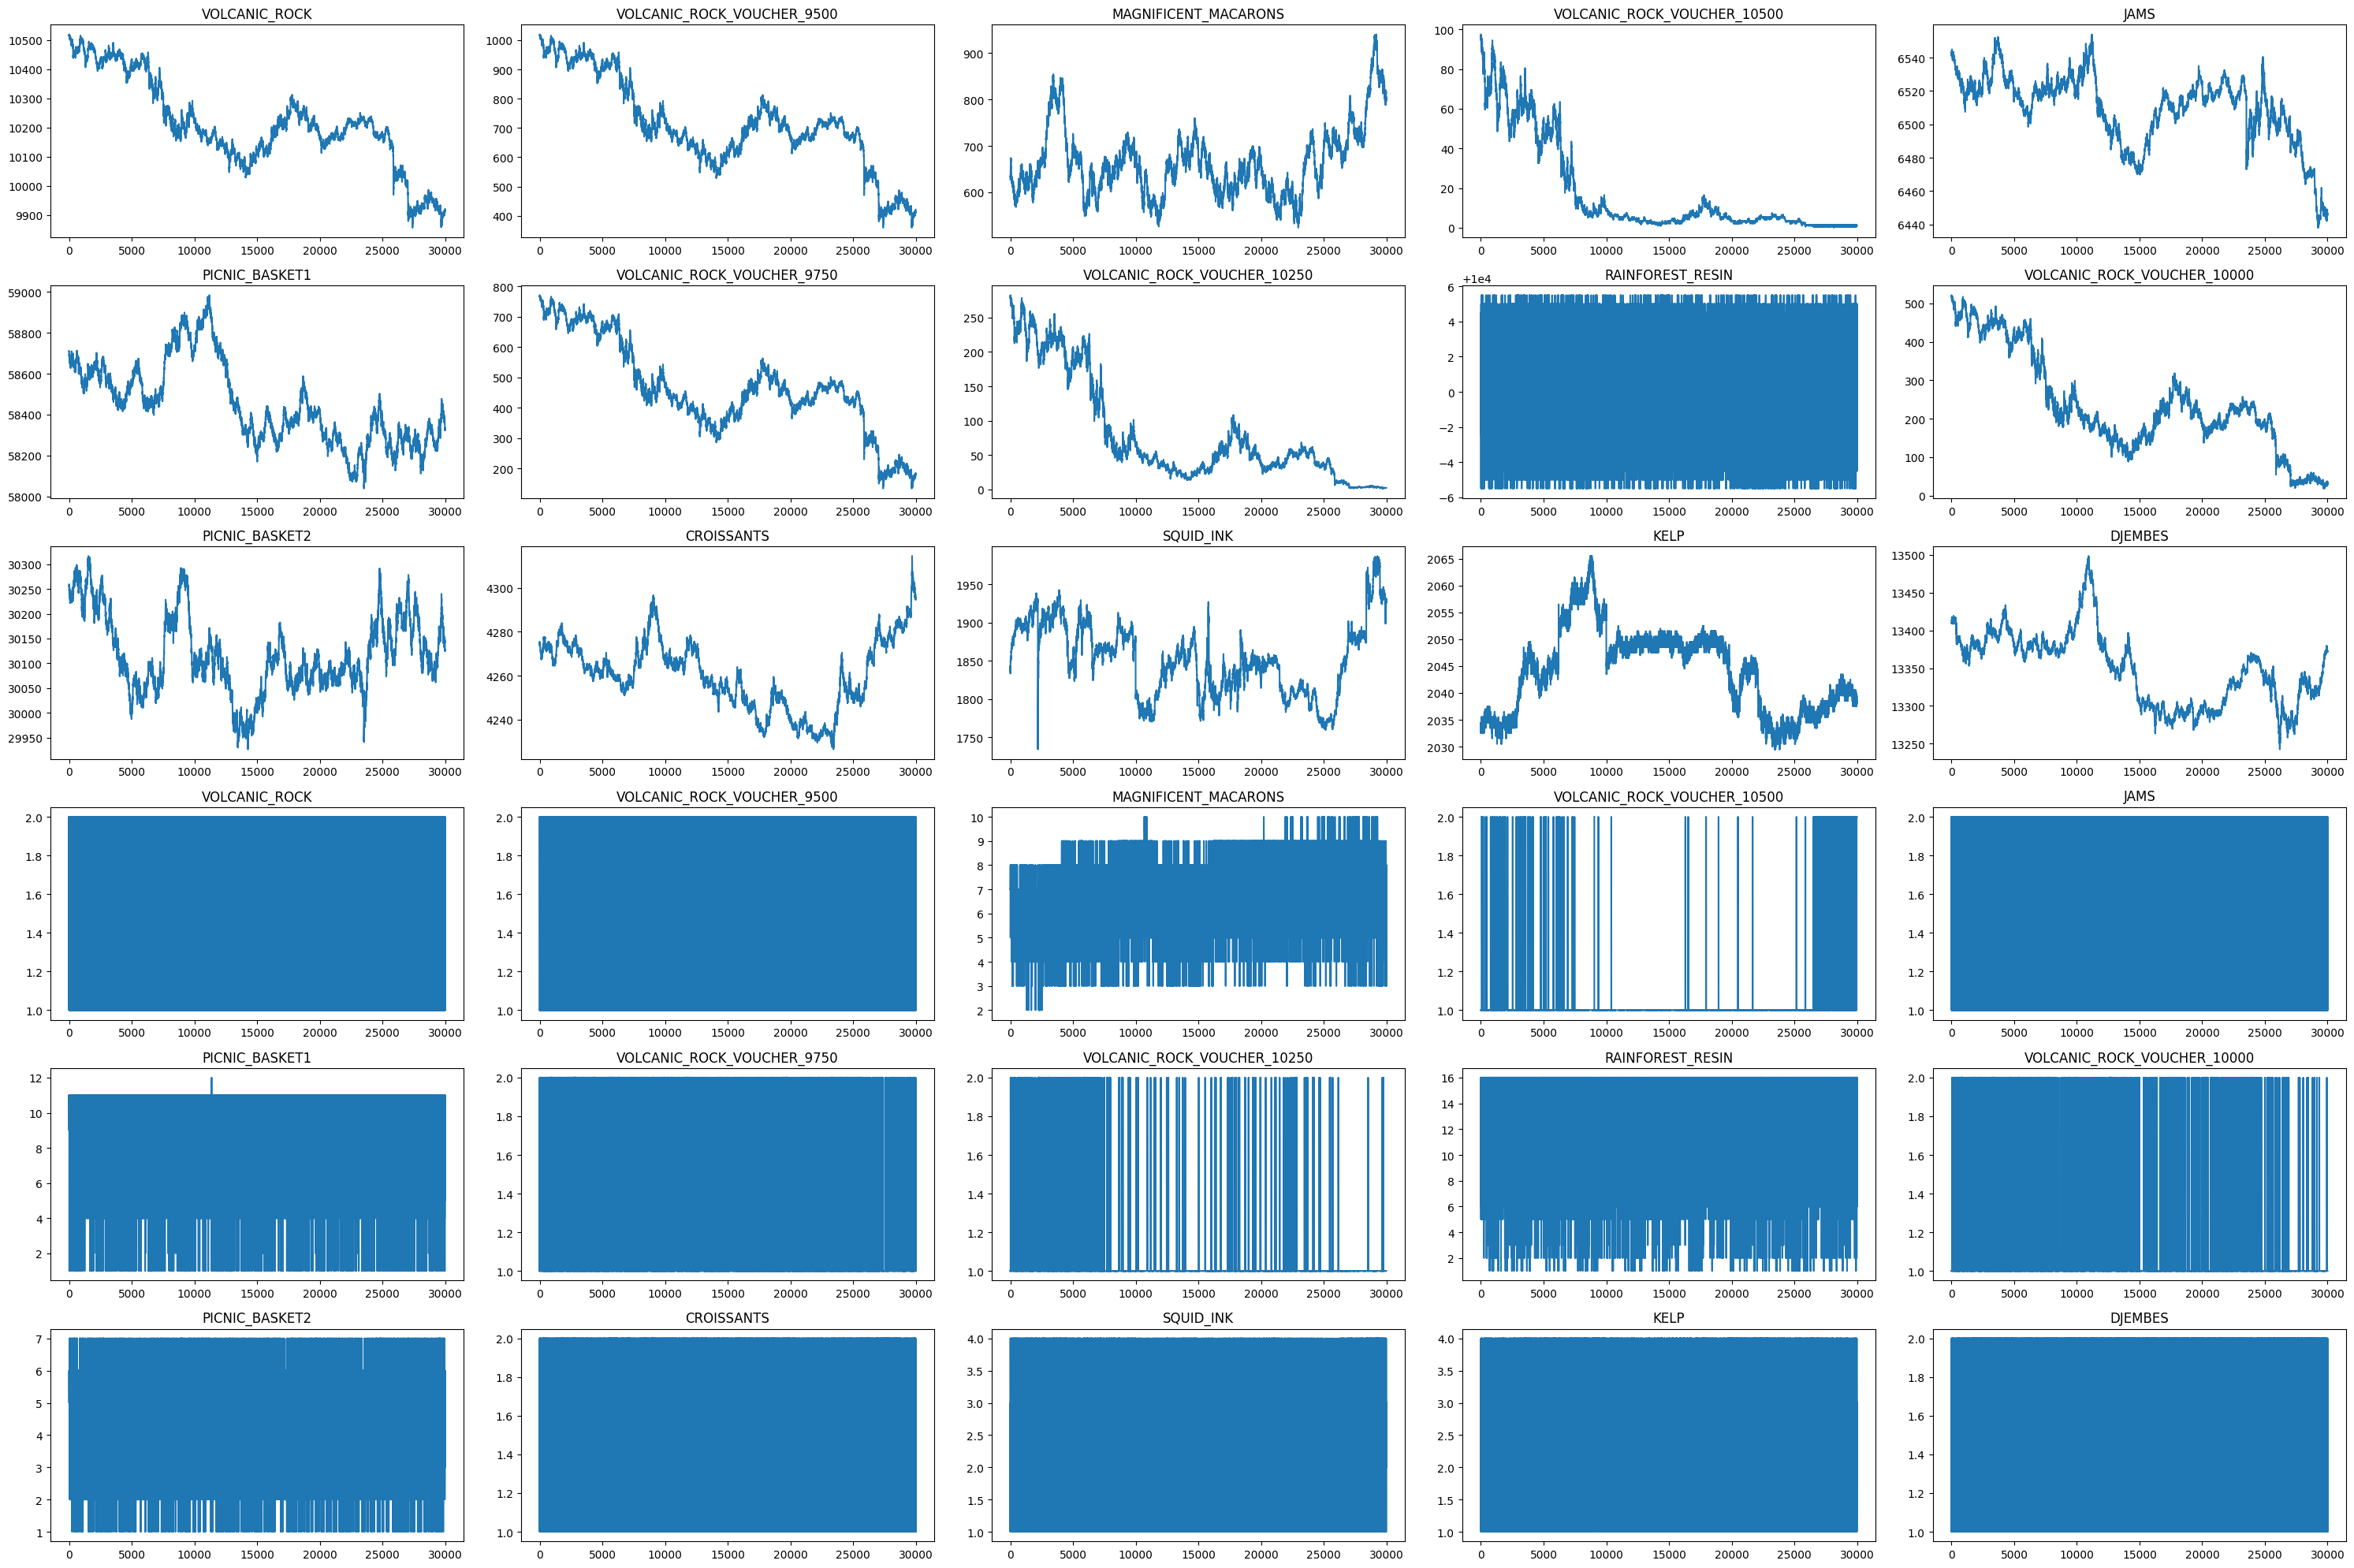

In [15]:
fig,ax = plt.subplots(ncols=5,nrows=6,figsize=(30,20))
for i, key in enumerate(price_dfs):
    row_num = i%3
    col_num = i//3
    df = price_dfs[key]
    ax[row_num,col_num].plot(df.mid_price)
    ax[row_num,col_num].set_title(key)
    ax[row_num+3,col_num].plot(df.ask_price_1-df.bid_price_1)
    ax[row_num+3,col_num].set_title(key)
fig.tight_layout()

In [16]:
macarons_mid = price_dfs['MAGNIFICENT_MACARONS'].mid_price
picnic1_mid = price_dfs['PICNIC_BASKET1'].mid_price
picnic2_mid = price_dfs['PICNIC_BASKET2'].mid_price

In [17]:
from scipy.stats import linregress

highest_rsquare = 0
j = 0
for i in range(1,10000):
    shift_value = i
    basket_returns = (picnic1_mid - picnic1_mid.shift(shift_value))/picnic1_mid.shift(shift_value)
    actual_macarons_returns = (macarons_mid.shift(-shift_value) - macarons_mid)/macarons_mid
    array = pd.concat([basket_returns,actual_macarons_returns],axis=1).dropna().values
    r_value = (linregress(array[:,0], array[:,1])[2])**2
    if r_value > highest_rsquare:
        highest_rsquare = r_value
        j = i
print(j, highest_rsquare)

# plt.plot(basket_returns)
# plt.plot(actual_macarons_returns)

9214 0.3669449271868958


In [32]:
from scipy.stats import linregress

croissants_mid = price_dfs['CROISSANTS'].mid_price

highest_rsquare = 0
j = 0
for i in range(1,600):
    shift_value = i
    basket_returns = (croissants_mid - croissants_mid.shift(shift_value))/croissants_mid.shift(shift_value)
    actual_macarons_returns = (macarons_mid.shift(-shift_value) - macarons_mid)/macarons_mid
    array = pd.concat([basket_returns,actual_macarons_returns],axis=1).dropna().values
    r_value = (linregress(array[:,0], array[:,1])[2])**2
    if r_value > highest_rsquare:
        highest_rsquare = r_value
        j = i
print(j, highest_rsquare)

115 0.005428488002140523


In [33]:
from scipy.stats import linregress

croissants_mid = price_dfs['JAMS'].mid_price

highest_rsquare = 0
j = 0
for i in range(1,600):
    shift_value = i
    basket_returns = (croissants_mid - croissants_mid.shift(shift_value))/croissants_mid.shift(shift_value)
    actual_macarons_returns = (macarons_mid.shift(-shift_value) - macarons_mid)/macarons_mid
    array = pd.concat([basket_returns,actual_macarons_returns],axis=1).dropna().values
    r_value = (linregress(array[:,0], array[:,1])[2])**2
    if r_value > highest_rsquare:
        highest_rsquare = r_value
        j = i
print(j, highest_rsquare)

269 0.01625305778538974


In [34]:
from scipy.stats import linregress

croissants_mid = price_dfs['DJEMBES'].mid_price

highest_rsquare = 0
j = 0
for i in range(1,600):
    shift_value = i
    basket_returns = (croissants_mid - croissants_mid.shift(shift_value))/croissants_mid.shift(shift_value)
    actual_macarons_returns = (macarons_mid.shift(-shift_value) - macarons_mid)/macarons_mid
    array = pd.concat([basket_returns,actual_macarons_returns],axis=1).dropna().values
    r_value = (linregress(array[:,0], array[:,1])[2])**2
    if r_value > highest_rsquare:
        highest_rsquare = r_value
        j = i
print(j, highest_rsquare)

439 0.013910223124565238


In [36]:
from scipy.stats import linregress

croissants_mid = price_dfs['SQUID_INK'].mid_price

highest_rsquare = 0
j = 0
for i in range(1,600):
    shift_value = i
    basket_returns = (croissants_mid - croissants_mid.shift(shift_value))/croissants_mid.shift(shift_value)
    actual_macarons_returns = (macarons_mid.shift(-shift_value) - macarons_mid)/macarons_mid
    array = pd.concat([basket_returns,actual_macarons_returns],axis=1).dropna().values
    r_value = (linregress(array[:,0], array[:,1])[2])**2
    if r_value > highest_rsquare:
        highest_rsquare = r_value
        j = i
print(j, highest_rsquare)

104 0.01049182987339691


KeyboardInterrupt: 

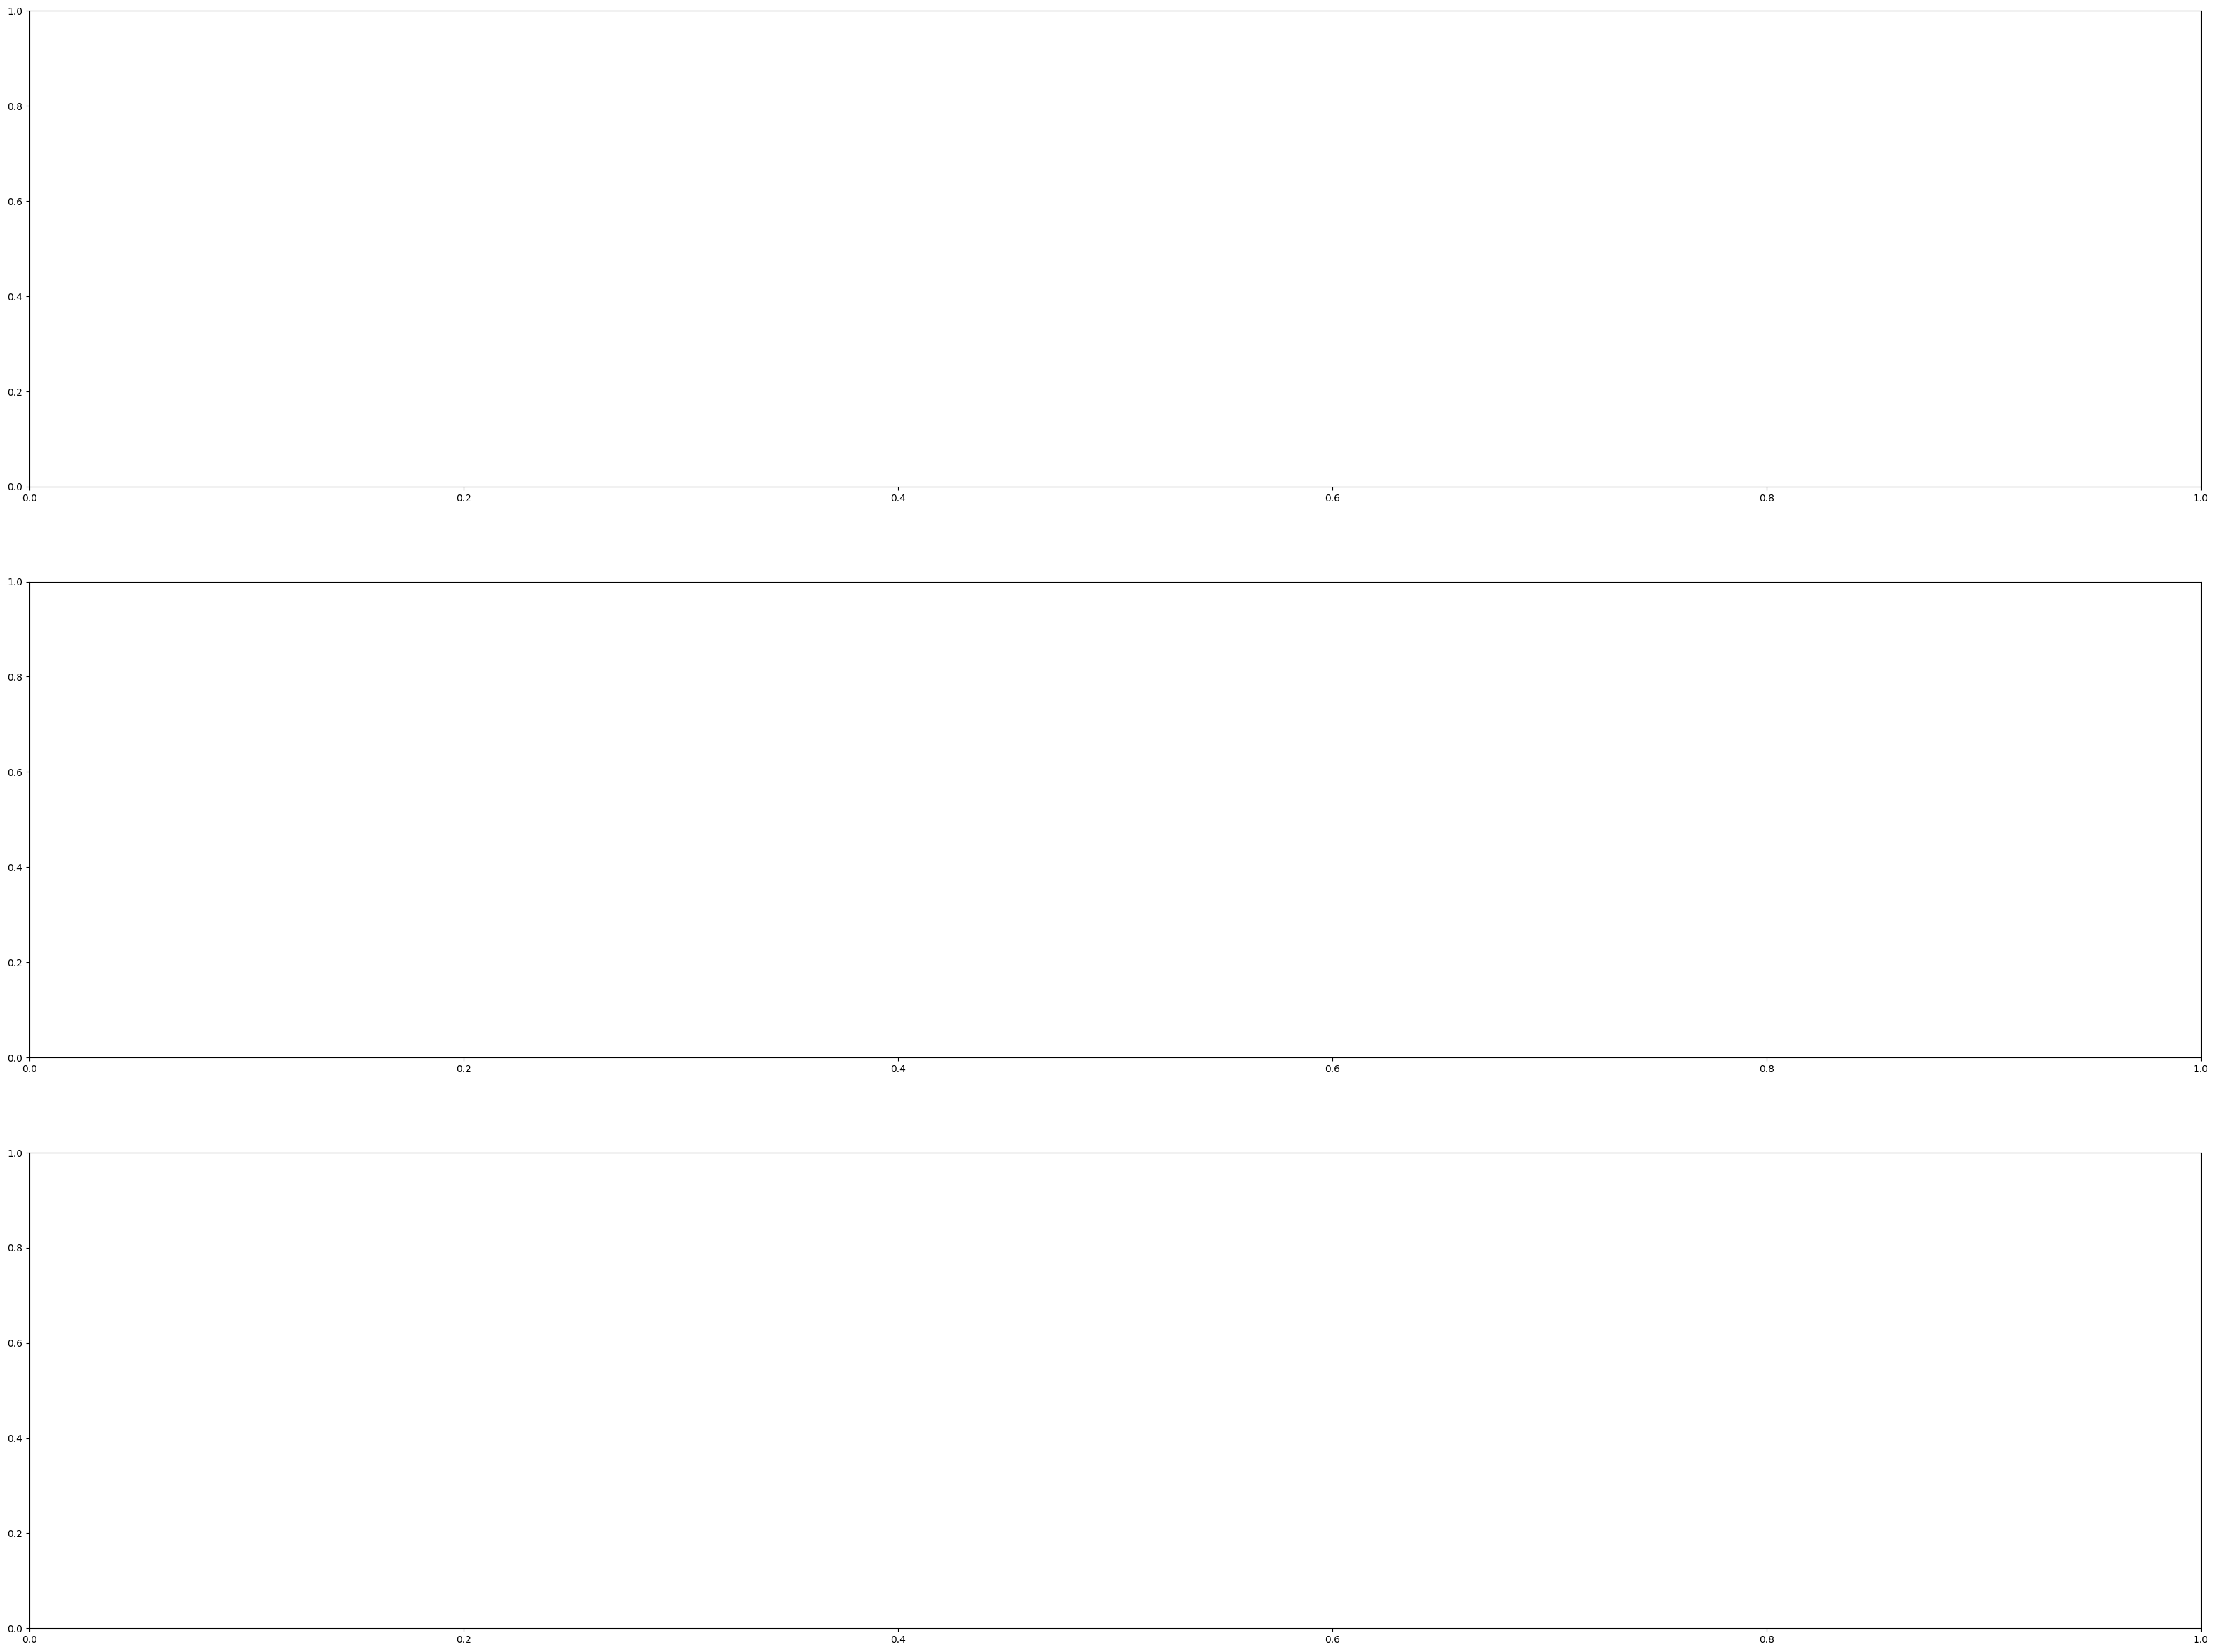

In [35]:
fig,ax = plt.subplots(nrows=3,figsize=(40,30))

best_pnl = 0
params = None
for i in range(2,20):
    for j in range(25,60):
        for k in range(3,30):
            fast = i
            slow = j
            window_of_macd = k
            macd = price_dfs['DJEMBES'].mid_price.rolling(fast).mean()-price_dfs['DJEMBES'].mid_price.rolling(slow).mean()
            macd_macd = macd.rolling(window_of_macd).mean()
            signal = np.sign(np.sign(macd-macd_macd).diff().replace(0,np.nan).ffill())
            final = (signal*price_dfs['DJEMBES'].mid_price.diff().shift(-1)).fillna(0).cumsum().iloc[-1]
            if final > best_pnl:
                best_pnl = final
                params = (fast, slow, window_of_macd)
fast, slow, window_of_macd = params
ax[0].plot(price_dfs['DJEMBES'].mid_price)
ax[0].plot(price_dfs['DJEMBES'].mid_price.rolling(fast).mean())
ax[0].plot(price_dfs['DJEMBES'].mid_price.rolling(slow).mean())
macd = price_dfs['DJEMBES'].mid_price.rolling(fast).mean()-price_dfs['DJEMBES'].mid_price.rolling(slow).mean()
macd_macd = macd.rolling(window_of_macd).mean()
ax[1].plot(macd)
ax[1].plot(macd_macd)
signal = np.sign(np.sign(macd-macd_macd).diff().replace(0,np.nan).ffill())
ax[2].plot((signal*price_dfs['DJEMBES'].mid_price.diff().shift(-1)).cumsum())

In [19]:
params

(3, 45, 3)

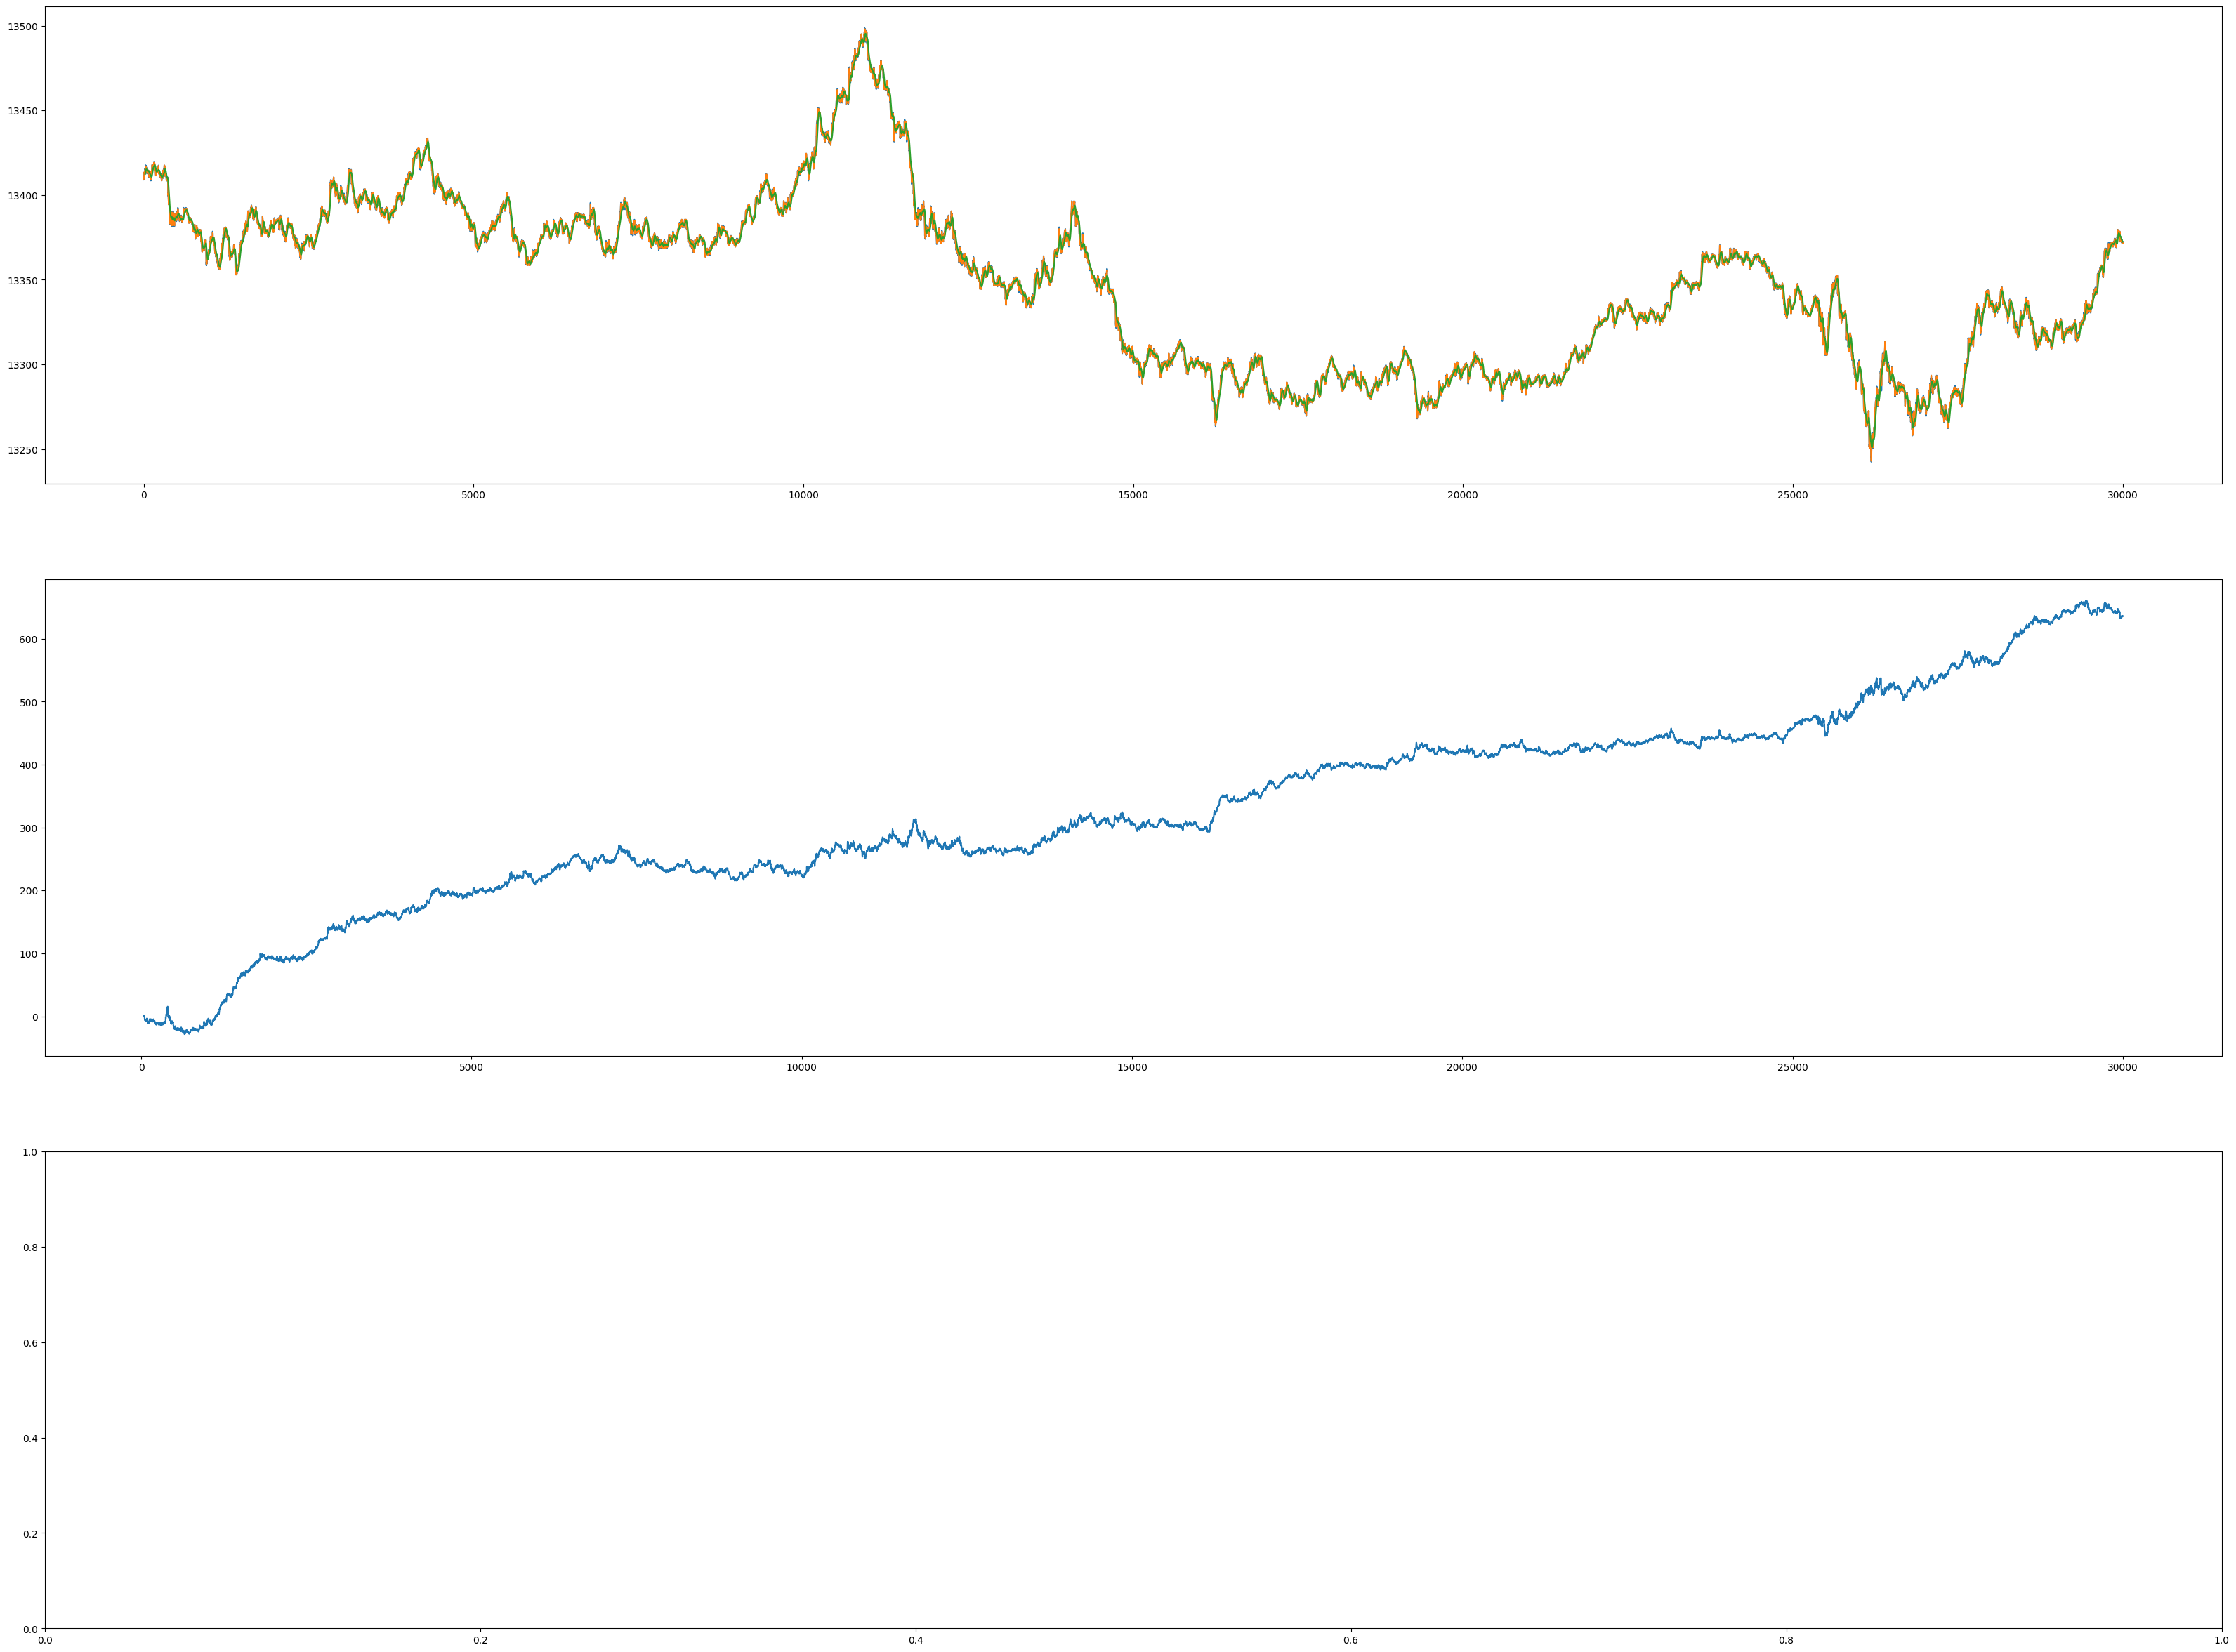

In [20]:
fig,ax = plt.subplots(nrows=3,figsize=(40,30))

best_pnl = 0
params = None
for i in range(2,20):
    for j in range(25,60):
        fast = i
        slow = j
        signal = np.sign(np.sign(price_dfs['DJEMBES'].mid_price.rolling(fast).mean()-price_dfs['DJEMBES'].mid_price.rolling(slow).mean()).diff().replace(0,np.nan).ffill())
        final = (signal*price_dfs['DJEMBES'].mid_price.diff().shift(-1)).fillna(0).cumsum().iloc[-1]
        if final > best_pnl:
            best_pnl = final
            params = (fast, slow, window_of_macd)
fast, slow, window_of_macd = params
ax[0].plot(price_dfs['DJEMBES'].mid_price)
ax[0].plot(price_dfs['DJEMBES'].mid_price.rolling(fast).mean())
ax[0].plot(price_dfs['DJEMBES'].mid_price.rolling(slow).mean())
signal = np.sign(np.sign(price_dfs['DJEMBES'].mid_price.rolling(fast).mean()-price_dfs['DJEMBES'].mid_price.rolling(slow).mean()).diff().replace(0,np.nan).ffill())
ax[1].plot((signal*price_dfs['DJEMBES'].mid_price.diff().shift(-1)).cumsum())

In [21]:
params

(2, 25, 3)

In [22]:
import sys
import os
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..')))

from utilities.log_processor import LogProcessor
processor = LogProcessor('../../logs/djembes_macd@19_04_2025_0134.log')
processor.read_log()

In [23]:
price_dat = processor.activities_log

In [24]:
djembes = price_dat[price_dat['product']=='DJEMBES'].reset_index(drop=True)

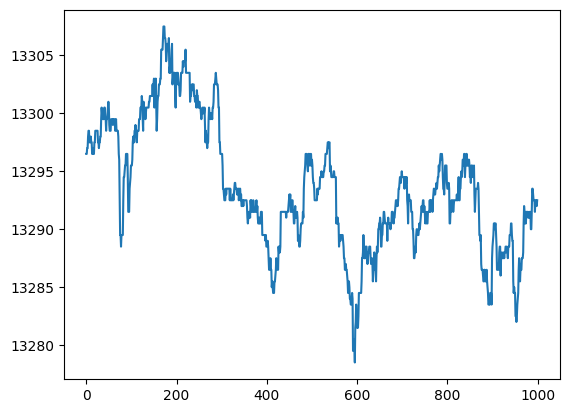

In [25]:
plt.plot(djembes.mid_price)

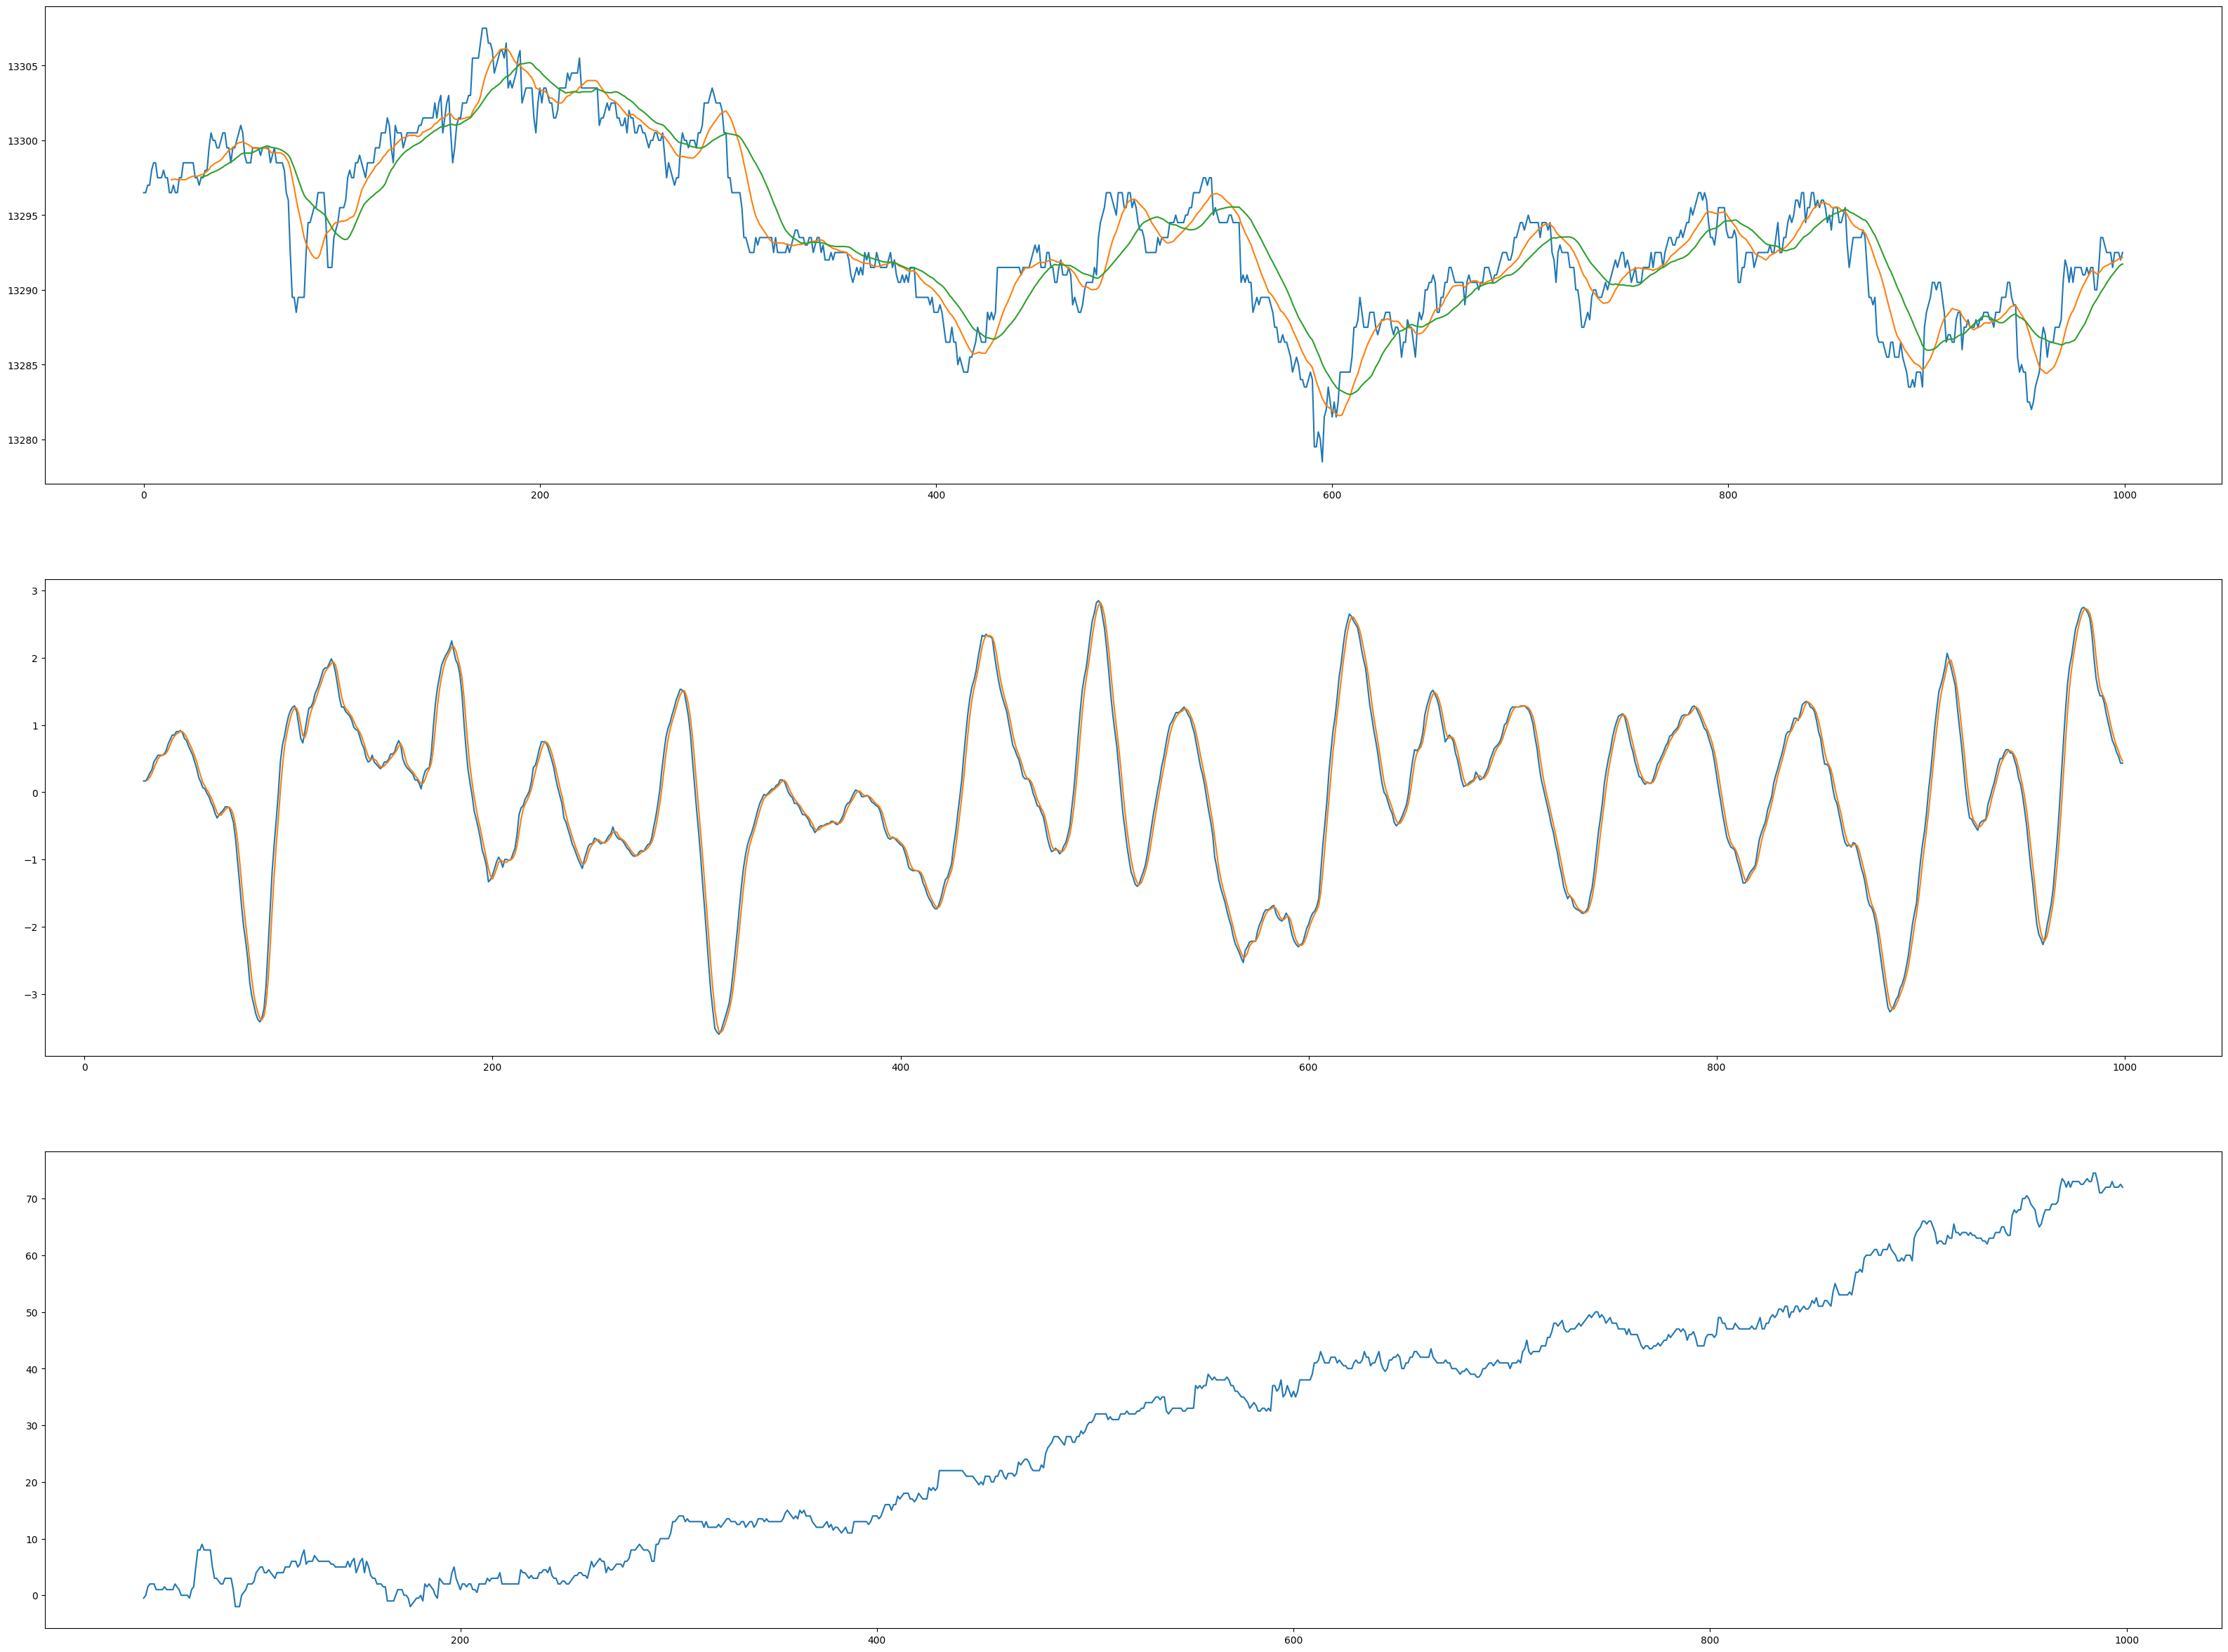

In [27]:
fig,ax = plt.subplots(nrows=3,figsize=(40,30))

best_pnl = 0
params = None
for i in range(2,20):
    for j in range(25,60):
        for k in range(3,30):
            fast = i
            slow = j
            window_of_macd = k
            macd = djembes.mid_price.rolling(fast).mean()-djembes.mid_price.rolling(slow).mean()
            macd_macd = macd.rolling(window_of_macd).mean()
            signal = np.sign(np.sign(macd-macd_macd).diff().replace(0,np.nan).ffill())
            final = (signal*djembes.mid_price.diff().shift(-1)).fillna(0).cumsum().iloc[-1]
            if final > best_pnl:
                best_pnl = final
                params = (fast, slow, window_of_macd)
fast, slow, window_of_macd = params
ax[0].plot(djembes.mid_price)
ax[0].plot(djembes.mid_price.rolling(fast).mean())
ax[0].plot(djembes.mid_price.rolling(slow).mean())
macd = djembes.mid_price.rolling(fast).mean()-djembes.mid_price.rolling(slow).mean()
macd_macd = macd.rolling(window_of_macd).mean()
ax[1].plot(macd)
ax[1].plot(macd_macd)
signal = np.sign(np.sign(macd-macd_macd).diff().replace(0,np.nan).ffill())
ax[2].plot((signal*djembes.mid_price.diff().shift(-1)).cumsum())

In [28]:
params



(15, 30, 3)